<a href="https://colab.research.google.com/github/GasserElbanna/voice-speech-metamers/blob/deepfake/Deepfake_Analysis_SpeakerDistance_vs_Rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install speechbrain

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [43]:
from collections import defaultdict

import torch
import torchaudio
import IPython
import os
import glob
import pandas as pd
import numpy as np
from transformers import Wav2Vec2Model
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from speechbrain.inference.encoders import WaveformEncoder
import matplotlib.pyplot as plt

In [3]:
%%capture
!pip install datasets -U
!pip install librosa
!pip install jiwer

https://huggingface.co/openai/whisper-medium

In [6]:
# !pip install --upgrade pyarrow

In [4]:
# prompt: mount my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Models

In [5]:
# load model and processor
processor = WhisperProcessor.from_pretrained("openai/whisper-base", language='en')
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base")
model.config.forced_decoder_ids = None


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/3.81k [00:00<?, ?B/s]

# Whisper Analysis

In [7]:
## list all the audios in the fake and real dataset
real_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/*.wav')
fake_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE_PARSED/*.wav')

In [ ]:
transcript_real = pd.DataFrame()
transcript_fake = pd.DataFrame()

real_speech = []
fake_speech = []

target_length = 20 # number of seconds
sr = 16000
num_samples = int(target_length * sr)

resampler = torchaudio.transforms.Resample(44100, 16000)

for i in range(len(real_files_list)):
  real_audio, sr_audio = torchaudio.load(real_files_list[i])
  real_audio = resampler(real_audio)
  # Chop off the audio to target length
  input_real_audio = real_audio[0,:num_samples]
  input_features = processor(input_real_audio, sampling_rate=sr, return_tensors="pt").input_features
  predicted_ids = model.generate(input_features)
  # decode token ids to text
  transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)
  real_speech.append(transcription)


transcript_real['Audio_Name'] = real_files_list
transcript_real['Transcription'] = real_speech

for i in range(len(fake_files_list)):
  fake_audio, sr_audio = torchaudio.load(fake_files_list[i])
  fake_audio = resampler(fake_audio)
  # Chop off the audio to target length
  input_fake_audio = fake_audio[0,:num_samples]
  input_features = processor(input_fake_audio, sampling_rate=sr, return_tensors="pt").input_features
  predicted_ids = model.generate(input_features)
  # decode token ids to text
  transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)
  fake_speech.append(transcription)


transcript_fake['Audio_Name'] = fake_files_list
transcript_fake['Transcription'] = fake_speech




Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
# prompt: create a new pandas dataframe

transcript_real.head()

,Audio_Name,Transcription
0,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ my fellow Americans. And the people abroad m...
1,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,"[ I see my buddy, Senator Tom Corporer down th..."
2,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ around him. Is that Ruth Ann? And that forme...
3,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ sisters law my sister Valerie anywhere folks...
4,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,"[ They've delivered us a clear victory, a conv..."


In [ ]:
transcript_fake.head()

,Audio_Name,Transcription
0,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ And I wouldn't be the man I am today without...
1,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ Let me say this public we Michelle]
2,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ I have never loved you more. I have never be...
3,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ Yay!]
4,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ Sasha Malia for our very eyes We're growing ...


In [ ]:
# prompt: how to save csv
transcript_real.to_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_real_snippets.csv', index=False)
transcript_fake.to_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_fake_snippets.csv', index=False)


In [ ]:
real_audio, sr = torchaudio.load('/content/drive/MyDrive/AUDIO/REAL/biden-original.wav')
fake_audio, sr = torchaudio.load('/content/drive/MyDrive/AUDIO/FAKE/biden-to-margot.wav')
resampler = torchaudio.transforms.Resample(sr, 16000)
real_audio = resampler(real_audio)
fake_audio = resampler(fake_audio)
sr = 16000

In [ ]:
target_length = 20 # number of seconds
num_samples = int(target_length * sr)
input_speech_real = real_audio[0,:num_samples]
input_speech_fake = fake_audio[0,:num_samples]
input_features_real = processor(input_speech_real, sampling_rate=sr, return_tensors="pt").input_features
input_features_fake = processor(input_speech_fake, sampling_rate=sr, return_tensors="pt").input_features

In [ ]:
# generate token ids
predicted_ids = model.generate(input_features_real)
# decode token ids to text
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=False)

transcription_real = processor.batch_decode(predicted_ids, skip_special_tokens=True)

# generate token ids
predicted_ids = model.generate(input_features_fake)
# decode token ids to text
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=False)

transcription_fake = processor.batch_decode(predicted_ids, skip_special_tokens=True)

In [ ]:
transcription_real

[' my fellow Americans and the people abroad me the dance Delawareans I see my buddy Tom Senator Tom Carpenter down there and I think Senator Kuhn']

In [ ]:
transcription_fake

[" my fellow Americans and the people of parliament dance, the Deleureans. I see my buddy, Senator Tom Carpardown there and I think Senator Coons is there and I think the governor's"]

# ECAPA-TDNN Analysis
#### https://huggingface.co/speechbrain/spkrec-ecapa-voxceleb

In [8]:
from speechbrain.inference.speaker import SpeakerRecognition
from speechbrain.inference.speaker import EncoderClassifier

In [10]:
verification = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/spkrec-ecapa-voxceleb")


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

In [14]:
real_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL/*.wav')
fake_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE/*.wav')

In [15]:
## generate combinations of two files
# prompt: given a list of files how can i generate all the possible combinations of choosing two files

from itertools import combinations

def generate_combinations(file_list):
  """
  Generates all possible combinations of choosing two files from a list.

  Args:
    file_list: A list of file paths.

  Returns:
    A list of tuples, where each tuple contains two file paths.
  """
  return list(combinations(file_list, 2))

combinations_real = generate_combinations(real_files_list)
combinations_fake = generate_combinations(fake_files_list)

In [17]:
len(combinations_fake)

1540

In [ ]:
speaker_verification_real = pd.DataFrame()

real_speakers = []
real_speakers_score = []

for i in range(len(combinations_real)):
  score, prediction = verification.verify_files(combinations_real[i][0], combinations_real[i][1])
  real_speakers.append(prediction)
  real_speakers_score.append(score)

speaker_verification_real['Audio_1'] = [x[0] for x in combinations_real]
speaker_verification_real['Audio_2'] = [x[1] for x in combinations_real]
speaker_verification_real['Are the two speakers same?'] = real_speakers
speaker_verification_real['Score'] = real_speakers_score


In [ ]:
speaker_verification_real.to_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/speaker_verification_real_snippet.csv', index=False)

In [ ]:
speaker_verification_fake = pd.DataFrame()

fake_speakers = []
fake_speakers_score = []


target_length = 20 # number of seconds
sr = 16000
num_samples = int(target_length * sr)

resampler = torchaudio.transforms.Resample(44100, 16000)

for i in range(len(combinations_fake)):
# for i in range(250):
  if i % 100 == 0:
    print(i)
  fake_audio, sr_audio = torchaudio.load(combinations_fake[i][0])
  fake_audio = resampler(fake_audio)
  # Chop off the audio to target length
  input_audio_1 = fake_audio[0,:num_samples]
  fake_audio, sr_audio = torchaudio.load(combinations_fake[i][1])
  fake_audio = resampler(fake_audio)
  # Chop off the audio to target length
  input_audio_2 = fake_audio[0,:num_samples]
  score, prediction = verification.verify_batch(input_audio_1,input_audio_2)
  fake_speakers.append(prediction)
  fake_speakers_score.append(score)

speaker_verification_fake['Audio_1'] = [x[0] for x in combinations_fake]
speaker_verification_fake['Audio_2'] = [x[1] for x in combinations_fake]
speaker_verification_fake['Are the two speakers same?'] = fake_speakers
speaker_verification_fake['Score'] = fake_speakers_score


speaker_verification_fake.to_csv('/content/drive/MyDrive/AUDIO/speaker_verification_fake.csv', index=False)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500


In [ ]:
speaker_verification_fake = pd.DataFrame()
speaker_verification_fake['Audio_1'] = [combinations_fake[i][0] for i in range(250)]
speaker_verification_fake['Audio_2'] = [combinations_fake[i][1] for i in range(250)]
speaker_verification_fake['Are the two speakers same?'] = fake_speakers
speaker_verification_fake['Score'] = fake_speakers_score


speaker_verification_fake.to_csv('/content/drive/MyDrive/AUDIO/speaker_verification_fake.csv', index=False)

# Comparison with Human Rating

In [21]:
df = pd.read_csv('/content/sample_data/Copy of Voice_Identification_Experiment - Annesya.csv')

In [27]:
audio_path = df['Unnamed: 1'][22:]

In [31]:
audio_path.iloc[0]

'trump-to-taylor_40.wav'

In [35]:
speaker_verification_fake = pd.DataFrame()

fake_speakers_rating = []
fake_speakers_score_rating = []


target_length = 20 # number of seconds
sr = 16000
num_samples = int(target_length * sr)

resampler = torchaudio.transforms.Resample(44100, 16000)

for i in range(len(audio_path)):
  audio_1_path = os.path.join('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE_PARSED/',audio_path.iloc[i])
  audio_2_path = os.path.join(
      '/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/',
      audio_path.iloc[i].split('-')[0]+'-original_'+audio_path.iloc[i].split('_')[1])

  fake_audio, sr_audio = torchaudio.load(audio_1_path)
  fake_audio = resampler(fake_audio)
  input_audio_1 = fake_audio[0,:]
  fake_audio, sr_audio = torchaudio.load(audio_2_path)
  fake_audio = resampler(fake_audio)
  input_audio_2 = fake_audio[0,:]
  score, prediction = verification.verify_batch(input_audio_1,input_audio_2)
  fake_speakers_rating.append(prediction)
  fake_speakers_score_rating.append(score)


In [47]:
sub_1 = pd.read_csv('/content/sample_data/Voice_Identification_Experiment - Gasser.csv')
sub_2 = pd.read_csv('/content/sample_data/Voice_Identification_Experiment - Sagarika.csv')

In [49]:
sub_1_rating = sub_1['Unnamed: 4'][24:]
sub_2_rating = sub_2['Unnamed: 4'][24:]

In [50]:
sub_1_rating = [sub_1_rating.iloc[i] for i in range(len(sub_1_rating))]
sub_2_rating = [sub_2_rating.iloc[i] for i in range(len(sub_2_rating))]

In [51]:
len(sub_1_rating)

32

(0.0, 1.0)

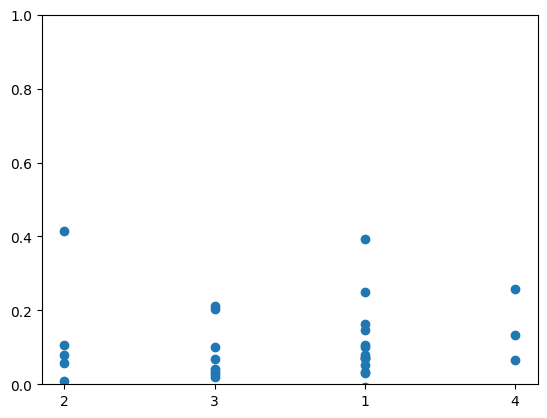

In [54]:
plt.figure()
plt.scatter(sub_1_rating, fake_speakers_score_rating)
plt.ylim([0,1])

(0.0, 1.0)

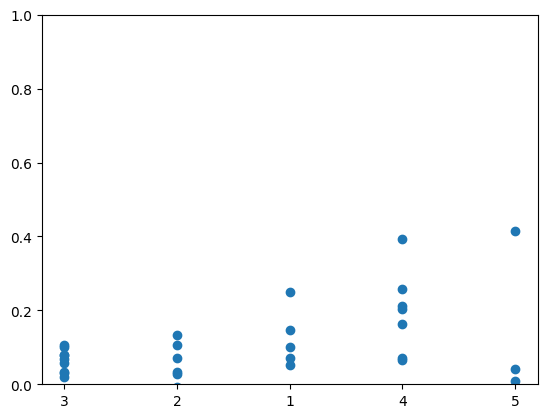

In [65]:
plt.figure()
plt.scatter(sub_2_rating, fake_speakers_score_rating_flat)
plt.ylim([0,1])

In [77]:
fake_speakers_score_rating_flat = [fake_speakers_score_rating[i][0][0] for i in range(len(fake_speakers_score_rating))]

In [82]:
sub_1_rating = [int(sub_1_rating[i]) for i in range(len(sub_1_rating))]
sub_2_rating = [int(sub_2_rating[i]) for i in range(len(sub_2_rating))]

In [83]:
sub_1_rating_scaled = 0.25*(np.array(sub_1_rating)-1)
sub_2_rating_scaled = 0.25*(np.array(sub_2_rating)-1)

In [86]:
print(np.corrcoef(sub_1_rating, np.array(fake_speakers_score_rating_flat))[0][1])
print(np.corrcoef(sub_2_rating, np.array(fake_speakers_score_rating_flat))[0][1])

0.017468956609667834
0.10801301938277899


In [ ]:
speaker_verification_fake['Audio_1'] = [x[0] for x in combinations_fake]
speaker_verification_fake['Audio_2'] = [x[1] for x in combinations_fake]
speaker_verification_fake['Are the two speakers same?'] = fake_speakers
speaker_verification_fake['Score'] = fake_speakers_score


speaker_verification_fake.to_csv('/content/drive/MyDrive/AUDIO/speaker_verification_fake.csv', index=False)